# Segmentation des images via l'API Higging Face

## 1. Importation des librairies et configuration initiale

### Importation des toutes les libs.

- `os` pour interagir avec le système de fichiers et les variables d'environnement.
- `base64` et `io` pour décoer les masques renvoyés par l'API.
- `requests` pour faire des appels à l'API.
- `time` pour gérer l'attent lorsque le rate limit est atteint.
- `numpy` pour la manipulation des tableaux (les images sont des tableaux de pixels).
- `matplotlib.pyplot` pour afficher les images et les masques.
- `dotenv` pour charger les variables d'environnement depuis le fichier .env.
- `matplotlib.colors` pour créer une palette de couleurs custom pour l'affichage des masques.
- `PIL (Pillow)` pour manipuler les images.
- `tqdm` pour afficher une barre de progression (utile pour plusieurs images).
- `concurrent.futures` pour traiter les images de manière concurante.

In [55]:
import os
import base64
import io
import requests
import time
import numpy as np
import matplotlib.pyplot as plt

from dotenv import load_dotenv
from matplotlib.colors import ListedColormap
from PIL import Image, ImageOps
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed

### Variables de configuration

- `IMAGE_DIR`: Le chemin vers le dossier contenant les images.
- `MAX_IMAGES`: Le nombre maximum d'images à traiter.
- `MAX_WORKERS`: Le nombre maximum de workers en simultané pour traiter les images
- `OUTPUT_DIR`: Chemin vers le dossier ou serons sauvegardés les masques prédits.
- `API_TOKEN`: Le jeton hugging face pour s'authentifier à l'API.
- `API_URL`: L'url de l'API hugging face pour acceder au model.

In [56]:
# Charger les variables d'environnement depuis le fichier .env
load_dotenv()

# Déffinir les constantes
IMAGE_DIR = "../data/IMG"
MAX_IMAGES = 3#50
MAX_WORKERS = 2

OUTPUT_DIR = "../data/Results"

# API_TOKEN et API_URL sont chargés depuis les variables d'environnement
API_TOKEN = os.getenv("HUGGING_FACE_ACCESS_TOKEN")
API_URL = os.getenv("HUGGING_FACE_API_URL")

# S'assurer que API_TOKEN et API_URL sont configurés
if API_TOKEN is None:
    raise RuntimeError("Erreur: La variable d'environnement 'HUGGING_FACE_ACCESS_TOKEN' n'est pas définie.")
if API_URL is None:
    raise RuntimeError("Erreur: La variable d'environnement 'HUGGING_FACE_API_URL' n'est pas définie.")

# S'assurer que le dossier d'images existe
if not os.path.isdir(IMAGE_DIR):
    raise FileNotFoundError(f"Erreur: Le dossier d'images à {IMAGE_DIR} n'a pas été trouvé.")

# S'assurer que le dossiers de sortie (Output) existe
if not os.path.isdir(OUTPUT_DIR):
    os.mkdir(OUTPUT_DIR)

## 2. Récupérer les chemins des images à traiter et les envoyer à l'API + Récupérer les chemins des masques

- `get_image_paths`: Récupérer les chemins vers les images.

In [57]:
def get_image_paths(dir_path: str = IMAGE_DIR, max_images: int | None = MAX_IMAGES) -> list[str]:
    """
    Get all image paths at the root of a directory

    Args:
        dir_path (str): Path to the folder.
        max_images (int | None): Max images count.

    Returns:
        the list of all image paths of the specified folder
    """

    # Extensions possibles pour des images.
    image_extensions = (".jpg", ".jpeg", ".png", ".webp")
    # Lister tout les elements du dossier spécifié dans les paramètres de la fonction.
    directory_elements = sorted(os.listdir(dir_path))
    # Recréer les chemins complets avec dir_path + el
    directory_elements = map(lambda el: os.path.join(dir_path, el), directory_elements)
    # Créer un nouveau tableau en ne gardant que les éléments qui sont des fichiers.
    directory_files = [f for f in directory_elements if os.path.isfile(f)]
    # Filtrer les images (c'est une image si son extension est comprise dans image_extensions).
    directory_images = list(filter(lambda p: os.path.splitext(p)[1].lower() in image_extensions, directory_files))
    # S'assurer de ne pas dépasser le nombre max d'images à traiter
    if max_images:
        directory_images = directory_images[:max_images]

    if not directory_images:
        print(f"Aucunes image trouvée dans '{dir_path}', Veuillez y ajouter des images")
    else:
        print(f"{len(directory_images)} image(s) à traiter.")

    return directory_images

## 3. Fonctions utilitaires pour le traitement des masques

- `CLASS_MAPPING`: Un dictionnaire qui associe les noms des classes (ex: "Hat") à des identifiants numériques.
- `get_image_dimensions`: Récupérer les dimensions d'une image.
- `decode_base64_mask`: Décoder un masque de base64 en une image (tableau NumPy) et le redimensionner.
- `create_masks`: Combiner les masques de toute les classes détectées en un seul masque de segmentation final, où chaque pixel a la valeur de l'ID e sa classe.

In [58]:
CLASS_MAPPING = {
    "Background": 0,
    "Hat": 1,
    "Hair": 2,
    "Sunglasses": 3,
    "Upper-clothes": 4,
    "Skirt": 5,
    "Pants": 6,
    "Belt": 8,
    "Left-shoe": 9,
    "Right-shoe": 10,
    "Face": 11,
    "Left-leg": 12,
    "Right-leg": 13,
    "Left-arm": 14,
    "Right-arm": 15,
    "Bag": 16,
    "Scarf": 17
}

def get_image_dimensions(img_path: str) -> tuple[int, int]:
    """
    Get the dimensions of an image.

    Args:
        imh_path (str): Path to the image.

    Returns:
        tuple: (width, height) of the image.
    """

    original_image = Image.open(img_path)
    return original_image.size

def decode_base64_mask(base64_string: str, width: int, height: int) -> np.ndarray:
    """
    Decode a base64-encoded mask into a NumPy array.

    Args:
        base64_string (str): Base64-encoded mask.
        width (int): Target width.
        height (int): Target height.

    Returns:
        np.ndarray: Single-channel mask array.
    """

    mask_data = base64.b64decode(base64_string)
    mask_image = Image.open(io.BytesIO(mask_data))
    mask_array = np.array(mask_image)

    if len(mask_array.shape) == 3:
        mask_array = mask_array[:, :, 0] # Take first channel if RGB
    mask_image = Image.fromarray(mask_array).resize((width, height), Image.NEAREST)
    return np.array(mask_image)

def create_masks(results: list, width: int, height: int) -> np.ndarray:
    """
    Combine multiple class masks into a single segmentation mask.

    Args:
        results (list): List of dictionaries with 'label' and 'mask' keys.
        width (int): Target width.
        height (int): Target height.

    Returns:
        np.ndarray: Combined segmentation mask with class indices.
    """

    combined_mask = np.zeros((height, width), dtype=np.uint8)  # Initialize with Background (0)

    # Process non-Background masks first
    for result in results:
        label = result['label']
        class_id = CLASS_MAPPING.get(label, 0)

        if class_id == 0:  # Skip Background
            continue

        mask_array = decode_base64_mask(result['mask'], width, height)
        combined_mask[mask_array > 0] = class_id
    
    # Process Background last to ensure it doesn't overwrite other classes unnecessarily
    # (Though the model usually provides non-overlapping masks for distinct classes other than background)
    for result in results:
        if result['label'] == 'Background':
            mask_array = decode_base64_mask(result['mask'], width, height)
            # Apply background only where no other class has been assigned yet
            # This logic might need adjustment based on how the model defines 'Background'
            # For this model, it seems safer to just let non-background overwrite it first.
            # A simple application like this should be fine: if Background mask says pixel is BG, set it to 0.
            # However, a more robust way might be to only set to background if combined_mask is still 0 (initial value)
            combined_mask[mask_array > 0] = 0 # Class ID for Background is 0

    return combined_mask

## Sauvegarder les prédictions

- `save_prediction`: Sauvegarde une prédictions du model dans data/Results.
- `save_predictions`: Sauvegarde les prédictions du model

In [59]:
def save_prediction(
    segmentation_mask: np.ndarray,
    image_filename: str,
    output_directory: str = OUTPUT_DIR
) -> None:
    """
    Saves a segmentation mask as a grayscale PNG image.

    Args:
        segmentation_mask (np.ndarray): NumPy array containing class indices for each pixel (typically uint8).
        image_filename (str): Original filename or path used to derive the output filename.
        output_directory (str, optional): The directory where the mask will be saved. Defaults to the OUTPUT_DIR constant.
    """

    mask_image = Image.fromarray(segmentation_mask.astype(np.uint8), mode="L") 

    base_name = os.path.splitext(image_filename)[0]
    output_path = os.path.join(output_directory, f"{base_name}.png")

    mask_image.save(output_path)

## 4. Segmentation d'une seule image

- `CONTENT_TYPE_MA PPING`: Un dictionnaire qui associe les extensions des images (ex: ".png") à des 'Content-Type'.
- `get_content_type`: Fonction utilitaire pour récupérer le Content-Type d'une image via son extension.
- `send_image`: Envoi une image à l'API pour la segmenter.
- `resize_and_pad`: Redimensionne l'image en ajoutant des bordures noires pour garder le bon ratio.
- `segment_image`: Prend une image pour la segmenter.

In [60]:
CONTENT_TYPE_MAPPING = {
    ".jpg": "image/jpeg",
    ".jpeg": "image/jpeg",
    ".png": "image/png",
    ".webp": "image/webp"
}

def get_content_type(image_path: str) -> str:
    """
    Determine the content type of an image with its file extensions.

    Args:
        image_path (str): Path or filename of the image.

    Returns:
        str: The corresponding Content-Type (ex: 'image/jpeg').

    Raises:
        ValueError: If the file extension is not found in CONTENT_TYPE_MAPPING.
    """
    extention = os.path.splitext(image_path)[1].lower()
    content_type = CONTENT_TYPE_MAPPING.get(extention)

    if content_type is None:
        raise ValueError(f"L'extension {extention} pour le fichier {image_path} ne correspond pas à celle d'une image.")

    return content_type

def send_image(image: bytes, content_type: str) -> list[any]:
    """
    Send an image to the Hugging Face Inference API for clothing segmentation.

    Args:
        image (bytes): The raw binary data of the image to analyze.
        content_type (str): Content-Type of the image (ex: image/png).

    Returns:
        list[SegmentationResult]: A list of dictionaries, each containing the 'label' 
        of the detected clothing item, the confidence 'score', and the segmentation 'mask' in Base64.
    """

    # Setup les headers de la request pour y spécifier le token.
    headers = {
        "Authorization": f"Bearer {API_TOKEN}",
        "Content-Type": content_type
    }

    max_retries = 5
    backoff_factor = 2
    timeout_seconds = 30

    # Faire une requête au service avec 5 tries
    for attempt in range(max_retries):
        try:
            response = requests.post(
                API_URL,
                headers=headers,
                data=image,
                timeout=timeout_seconds
            )

            # Gérer les erreur de rate limit (429) ou d'indisponibilité du serveur (503)
            if response.status_code in [429, 503]:
                retry_after = response.headers.get("Retry-After")
                sleep_time = int(retry_after) if retry_after else (backoff_factor ** attempt)

                print(
                    f"API saturée ou indisponible (Code {response.status_code}). "
                    f"Tentative {attempt + 1}/{max_retries}. Attente de {sleep_time}s..."
                )
                time.sleep(sleep_time)
                continue

            if response.status_code != 200:
                raise requests.exceptions.HTTPError(f"Erreur API non récupérable: {response.status_code} - {response.text}")

            return response.json()

        # Gestion du Timeout
        except requests.exceptions.Timeout:
            sleep_time = backoff_factor ** attempt
            print(
                f"Timeout dépassé ({timeout_seconds}s) lors de la requête. "
                f"Tentative {attempt + 1}/{max_retries}. Nouvelle tentative dans {sleep_time}s..."
            )
            time.sleep(sleep_time)


        # Erreurs réseau critiques
        except requests.exceptions.RequestException as e:
            print(f"Erreur réseau critique : {e}")
            raise e

    raise Exception(f"Impossible de traiter l'image après {max_retries} tentatives en raison de Timeouts ou de limitations.")

def resize_and_pad(img: Image.Image, size=(600, 400)) -> Image.Image:
    """
    Resizes an image while maintaining aspect ratio and adds padding to reach target dimensions.

    Prevents distortion by centering the original image within the target size 
    and filling the background with black.

    Args:
        img (Image.Image): The source PIL Image object.
        size (tuple[int, int], optional): Target (width, height). Defaults to (600, 400).

    Returns:
        Image.Image: A new PIL Image with target dimensions and black padding.
    """

    target_size = size
    if (img.height > img.width) != (size[1] > size[0]):
        target_size = (size[1], size[0])

    return ImageOps.pad(img, target_size, method=Image.Resampling.LANCZOS, color=(0, 0, 0))

def segment_image(image_path: str) -> tuple[np.ndarray | None, float]:
    """
    Process a local image file to generate a unified segmentation mask.

    Args:
        image_path (str): The file system path to the image to be processed.

    Returns:
        tuple[np.ndarray | None, float]: Un tuple contenant :
            - Le masque de segmentation fusionné (tableau NumPy), ou None en cas d'erreur.
            - Le temps de traitement en secondes (lecture, appel API, fusion des masques et sauvegarde).
    """

    start = time.perf_counter()
    print(f"Traitement de l'image: {image_path}")

    try:
        # Initialiser la variable qui contient les données de l'image
        image_data: bytes = []
        # La taille de l'image redimensionné
        processed_w: int = 0
        processed_h: int = 0
        # Récupérer le Content-Type
        content_type = get_content_type(image_path)
        # Récupérer les dimensions de l'image
        image_width, image_height = get_image_dimensions(image_path)

        # Ouvir le fichier de l'image et lire son contenu pour le mettre dans 'image_data'
        with Image.open(image_path) as img:
            # Convertir l'image en RGB
            img = img.convert("RGB")
            # Rediensionner l'image
            image_resized = resize_and_pad(img)
            # 2. On récupère les dimensions réelles de cette image traitée
            processed_w, processed_h = image_resized.size
            # Sauveragrder l'image dans un buffer en mémoire
            buffer = io.BytesIO()
            image_resized.save(buffer, format="JPEG")
            # Mettre la valeur du buffer dans image_data
            image_data = buffer.getvalue()


        # Segmenter l'image en plusieurs masques via l'API
        segmentation_result = send_image(image_data, content_type)
        # Fusionner les masques récupéré via l'API en un seul masque
        final_mask = create_masks(segmentation_result, processed_w, processed_h)

        # Sauvegarder le masque predit
        save_prediction(final_mask, os.path.basename(image_path))

        processing_time = time.perf_counter() - start
        print(f"Image {os.path.basename(image_path)} segmenté en {processing_time:.2f}s")

        return final_mask, processing_time
        
    except Exception as e:
        print(f"Une erreur est survenue lors de la segmentation de l'image {image_path}: {e}")
        return None, time.perf_counter() - start

## 5. Segmentation de plusieurs images (batch)

`segment_images_batch`: Prend une liste d'image pour les segmenter.

In [61]:
def segment_images_batch(list_of_image_paths: list[str]) -> list[np.ndarray | None]:
    """
    Segment a list of images using the Hugging Face API.

    Args:
        list_of_image_paths (list[str]): A list of file paths to the images.

    Returns:
        list[np.ndarray | None]: A list of segmentation masks (NumPy arrays). 
        Contains None for any image that could not be processed.
    """

    # Préparer le tableau pour le stockage des resultats
    batch_segmentations: list[np.ndarray | None] = [None] * len(list_of_image_paths)

    # Stocke tout les temps de traitement des images pour en faire  une moyenne par la suite
    image_processing_times: list[float] = [0.0] * len(list_of_image_paths)

    start = time.perf_counter()

    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futute_to_index = {
            executor.submit(segment_image, path): i for i, path in enumerate(list_of_image_paths)
        }

        for future in tqdm(
            as_completed(futute_to_index),
            total=len(list_of_image_paths),
            desc="Segmentation en cours"
        ):
            # Index de l'image
            index = futute_to_index[future]
            try:
                batch_segmentations[index], image_processing_times[index] = future.result()
            except:
                batch_segmentations[index] = None
                image_processing_times[index] = 0.0

    total_processing_time = time.perf_counter() - start
    total = sum(image_processing_times)
    average = total / len(image_processing_times)
    print(f"Temps total: {total_processing_time:.2f}")
    print(f"Temps total (Somme des temps par images): {total:.2f} s")
    print(f"Temps moyen: {average:.2f} s")

    return batch_segmentations

## 6. Affichage des résultats

- `DISPLAY_COLORS`: Liste de couleurs pour chaque index (0 à 17) des masques
- `display_segmented_images_batch`: Affiche les images originales et leurs masques segmentés.

In [62]:
DISPLAY_COLORS = [
    "#000000",
    "#FF0000",
    "#00FF00",
    "#0000FF",
    "#FFFF00",
    "#FF00FF",
    "#00FFFF",
    "#808080",
    "#FFA500",
    "#800080",
    "#800000",
    "#FFC0CB",
    "#008080",
    "#808000",
    "#000080",
    "#FF4500",
    "#7FFF00",
    "#DC143C"
]

def display_segmented_images_batch(original_image_paths: list[str], segmentation_masks: list[np.ndarray]) -> None:
    """
    Displays the original images and their segmented masks.

    Args:
        original_image_paths (list[str]): List of paths to original images.
        segmentation_masks (list[np.ndarray | None]): List of segmentation masks as NumPy arrays.
    """

    images_count = len(original_image_paths)

    # Créé une figure avec 2 colones et n lignes (n = le nombre d'images)
    _, axes = plt.subplots(images_count, 2, figsize=(10, 5 * images_count))

    # S'assurer que axes reste une matrice en 2 dimensions même si il n'y a qu'une seul image
    # Car par defaut, si il n'y a qu'une seul ligne dans axes, Matplotlib renvoi un tableau simple au lieu d'un tableau de tableau.
    # Donc par exemple, si images_count == 1 -> axes == [axe1, axe2] -> np.expand_dims(...) -> axes == [[axe1, axe2]].
    if images_count == 1:
        axes = np.expand_dims(axes, axis=0)

    #...
    for i in range(images_count):
        # Charger et afficher l'image original
        try:
            image = Image.open(original_image_paths[i])
            axes[i, 0].imshow(image)
            axes[i, 0].set_title(f"Original: {i + 1}")
        except Exception as e:
            axes[i, 0].text(0.5, 0.5, f"Erreur lors du chargement de l'image {i + 1}", ha="center")
        
        axes[i, 0].axis("off")

        # Afficher le masque
        mask = segmentation_masks[i]

        if mask is not None:
            custom_cmap = ListedColormap(DISPLAY_COLORS)
            # Afficher le masque avec custom_cmap.
            # Viridis est la palette de couleur par defaut de Matplotlib.
            axes[i, 1].imshow(mask, cmap=custom_cmap)
            axes[i, 1].set_title(f"Masque: {i + 1}")
        else:
            axes[i, 0].text(0.5, 0.5, f"Erreur lors du masque {i + 1}", ha="center")

        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()

## Lancer le script

3 image(s) à traiter.
Traitement en batch des images...
Traitement de l'image: ../data/IMG\image_0.png
Traitement de l'image: ../data/IMG\image_1.png


Segmentation en cours:  33%|███▎      | 1/3 [00:04<00:08,  4.42s/it]

Image image_1.png segmenté en 4.42s
Traitement de l'image: ../data/IMG\image_10.png


Segmentation en cours:  67%|██████▋   | 2/3 [00:04<00:02,  2.10s/it]

Image image_0.png segmenté en 4.89s


Segmentation en cours: 100%|██████████| 3/3 [00:05<00:00,  1.98s/it]

Image image_10.png segmenté en 1.53s
Temps total: 5.95
Temps total (Somme des temps par images): 10.84 s
Temps moyen: 3.61 s
Traitement en batch terminé.


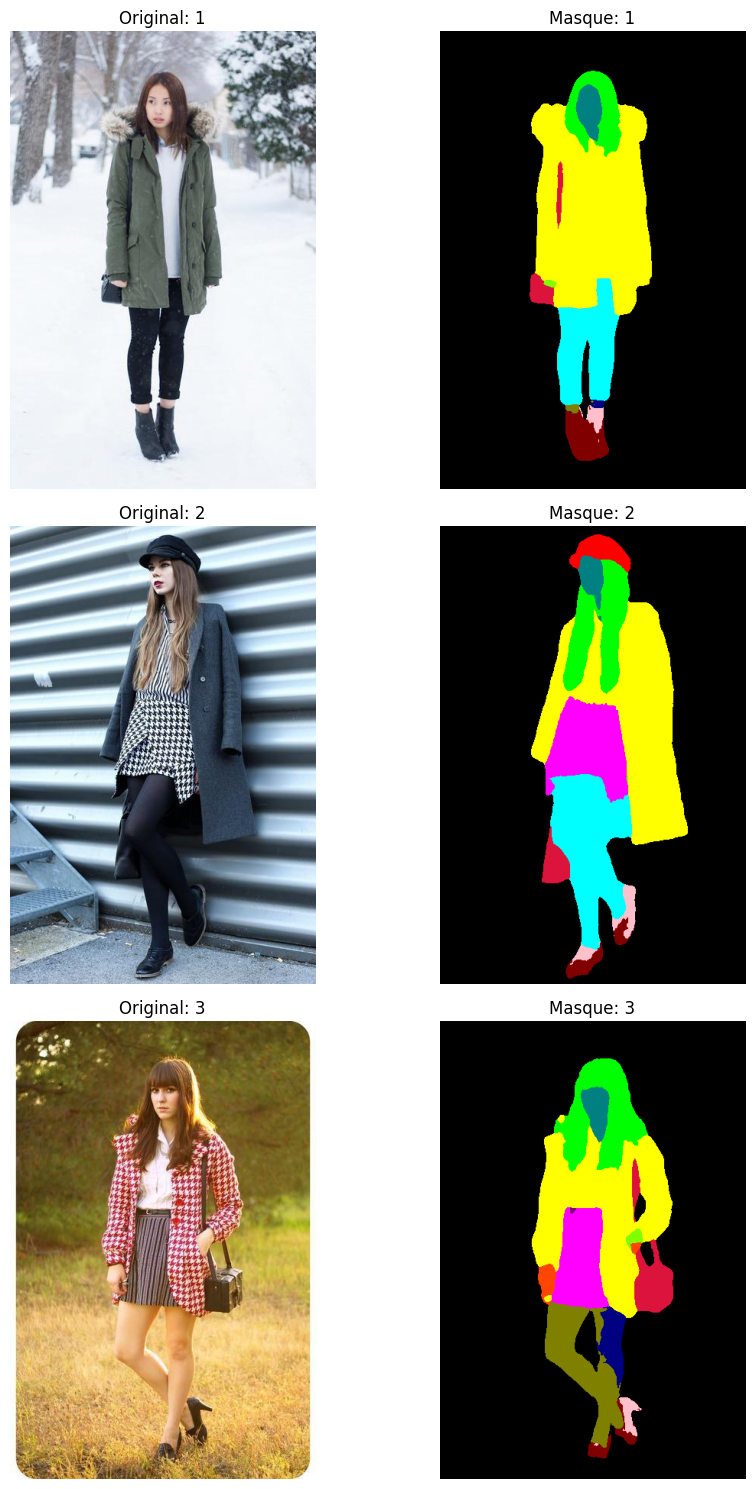

In [63]:
if __name__ == "__main__": # Pour s'assurer que c'est bien le fichier depuis lequel on a lancé le code
    image_paths = get_image_paths()

    # Si il n'y a pas d'images, quitter le programme.
    # 'get_image_paths' s'occupe déja d'afficher un message dans ce cas.
    if not image_paths:
        os.close(0)

    # Segmenter les images
    print("Traitement en batch des images...")
    batch_segmentation_results = segment_images_batch(image_paths)
    print("Traitement en batch terminé.")

    display_segmented_images_batch(image_paths, batch_segmentation_results)